**This notebook is to visulize CAPO prompt optimization results**

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
validation_dirs = [
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260128_1312"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260129_1043"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260129_1548"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260130_2022"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260131_1537"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260131_1849"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/active_prompting_batch_260131_2330"),
]
test_set_dirs = [
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260129_1459"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260129_1434"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260130_1929"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260130_2333"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260131_1723"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260201_1817"),
    Path("/Users/yaochenr/project/molecular_glue_extractor/output/results/260201_0042"),
]

In [2]:
all_rounds_data = {}

for val_dir in validation_dirs:
    for round_dir in val_dir.glob("round_*"):
        round_num = int(round_dir.name.split("_")[1])
        agg_file = round_dir / "aggregate_metrics.json"

        if agg_file.exists():
            with open(agg_file) as f:
                data = json.load(f)

            if round_num not in all_rounds_data:
                all_rounds_data[round_num] = {
                    'part1_precision': [],
                    'part1_recall': [],
                    'part2_precision': [],
                    'part2_recall': [],
                }

            all_rounds_data[round_num]['part1_precision'].append(data['avg_part1_precision'])
            all_rounds_data[round_num]['part1_recall'].append(data['avg_part1_recall'])
            all_rounds_data[round_num]['part2_precision'].append(data['avg_part2_precision'])
            all_rounds_data[round_num]['part2_recall'].append(data['avg_part2_recall'])

rounds = sorted(all_rounds_data.keys())
cross_val_metrics = {}

for r in rounds:
    cross_val_metrics[r] = {
        'avg_part1_precision': np.mean(all_rounds_data[r]['part1_precision']),
        'avg_part1_recall': np.mean(all_rounds_data[r]['part1_recall']),
        'avg_part2_precision': np.mean(all_rounds_data[r]['part2_precision']),
        'avg_part2_recall': np.mean(all_rounds_data[r]['part2_recall']),
        'std_part1_precision': np.std(all_rounds_data[r]['part1_precision']),
        'std_part1_recall': np.std(all_rounds_data[r]['part1_recall']),
        'std_part2_precision': np.std(all_rounds_data[r]['part2_precision']),
        'std_part2_recall': np.std(all_rounds_data[r]['part2_recall']),
        'num_tests': len(all_rounds_data[r]['part1_precision']),
    }

for r in rounds:
    print(f"Round {r}: {cross_val_metrics[r]['num_tests']} tests")

test_set_metrics = {
    'part1_precision': [],
    'part1_recall': [],
    'part2_precision': [],
    'part2_recall': [],
}

for test_dir in test_set_dirs:
    eval_file = test_dir / "record_based_evaluation_results.json"
    if eval_file.exists():
        with open(eval_file) as f:
            data = json.load(f)
        test_set_metrics['part1_precision'].append(data['part1_record_level']['precision_records'])
        test_set_metrics['part1_recall'].append(data['part1_record_level']['recall_records'])
        test_set_metrics['part2_precision'].append(data['part2_entry_level']['precision_entry'])
        test_set_metrics['part2_recall'].append(data['part2_entry_level']['recall_entry'])

test_set_avg = {
    'avg_part1_precision': np.mean(test_set_metrics['part1_precision']),
    'avg_part1_recall': np.mean(test_set_metrics['part1_recall']),
    'avg_part2_precision': np.mean(test_set_metrics['part2_precision']),
    'avg_part2_recall': np.mean(test_set_metrics['part2_recall']),
    'std_part1_precision': np.std(test_set_metrics['part1_precision']),
    'std_part1_recall': np.std(test_set_metrics['part1_recall']),
    'std_part2_precision': np.std(test_set_metrics['part2_precision']),
    'std_part2_recall': np.std(test_set_metrics['part2_recall']),
}

print(f"\nTest Set Averages (n={len(test_set_metrics['part1_precision'])}):")
print(f"  Part1 Precision: {test_set_avg['avg_part1_precision']:.4f} ± {test_set_avg['std_part1_precision']:.4f}")
print(f"  Part1 Recall:    {test_set_avg['avg_part1_recall']:.4f} ± {test_set_avg['std_part1_recall']:.4f}")
print(f"  Part2 Precision: {test_set_avg['avg_part2_precision']:.4f} ± {test_set_avg['std_part2_precision']:.4f}")
print(f"  Part2 Recall:    {test_set_avg['avg_part2_recall']:.4f} ± {test_set_avg['std_part2_recall']:.4f}")

Round 1: 7 tests
Round 2: 7 tests
Round 3: 3 tests

Test Set Averages (n=7):
  Part1 Precision: 0.9808 ± 0.0316
  Part1 Recall:    1.0000 ± 0.0000
  Part2 Precision: 0.9185 ± 0.1313
  Part2 Recall:    0.9333 ± 0.1151


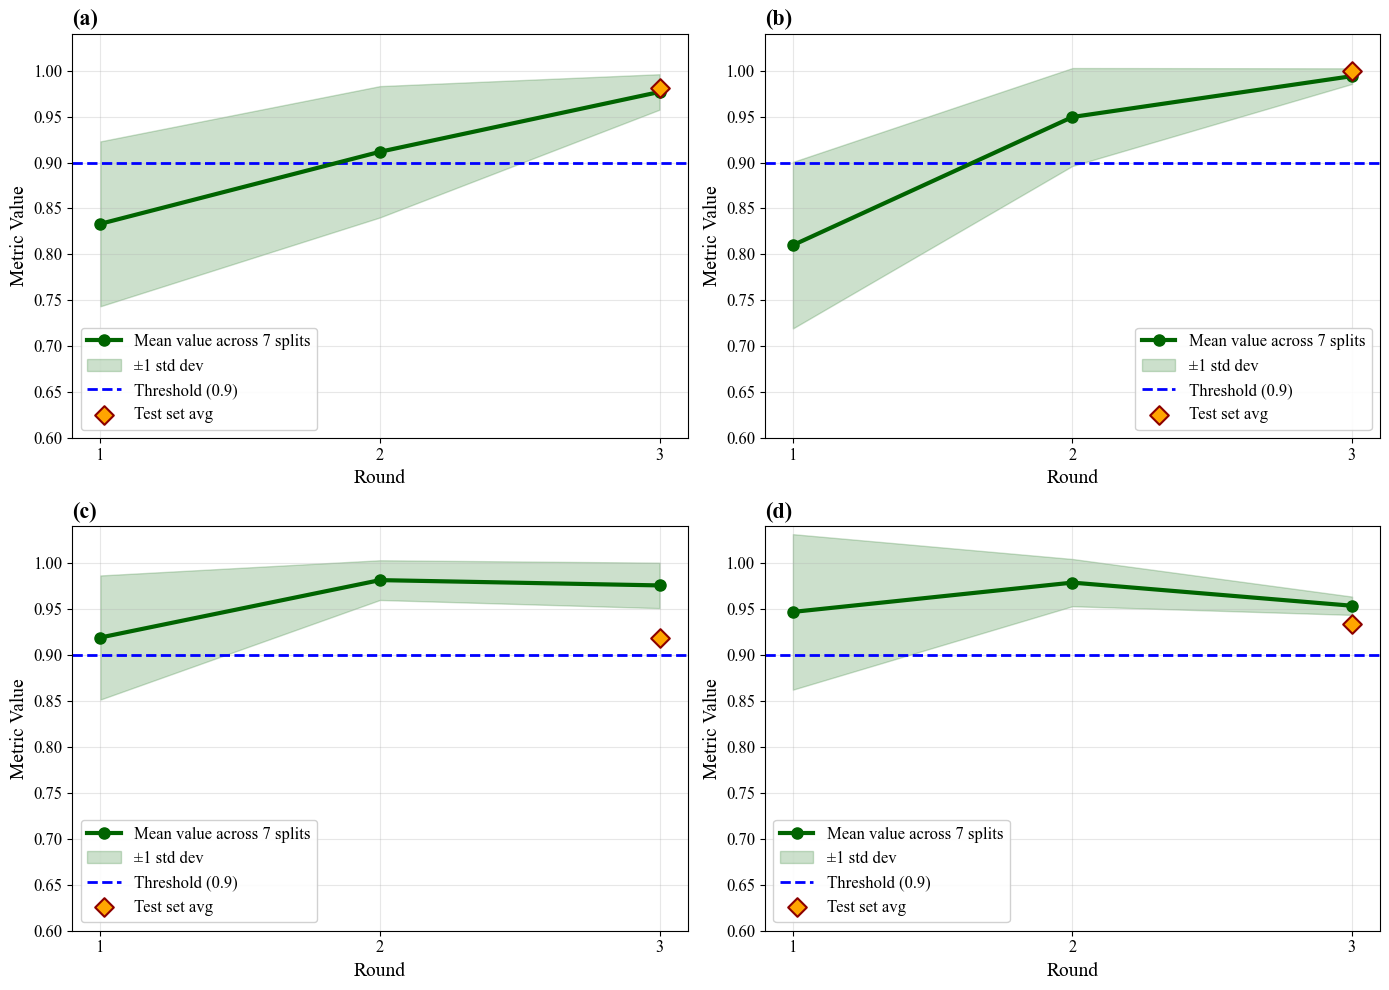

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_specs = [
    ('avg_part1_precision', 'std_part1_precision', "(a)"),
    ('avg_part1_recall', 'std_part1_recall', "(b)"),
    ('avg_part2_precision', 'std_part2_precision', "(c)"),
    ('avg_part2_recall', 'std_part2_recall', "(d)"),
]

threshold = 0.9

for idx, (metric_key, std_key, metric_title) in enumerate(metrics_specs):
    ax = axes[idx // 2, idx % 2]

    values = [cross_val_metrics[r][metric_key] for r in rounds]
    stds = [cross_val_metrics[r][std_key] for r in rounds]

    ax.plot(rounds, values, marker='o', color='darkgreen', linewidth=3,
           markersize=8, label='Mean value across 7 splits', zorder=3)

    upper = [v + s for v, s in zip(values, stds)]
    lower = [max(0, v - s) for v, s in zip(values, stds)]
    ax.fill_between(rounds, lower, upper, color='darkgreen', alpha=0.2,
                   label='±1 std dev')

    ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=2,
              label=f'Threshold ({threshold})')

    test_avg_value = test_set_avg[metric_key]
    last_round = max(rounds)
    ax.scatter([last_round], [test_avg_value], marker='D', s=90, color='orange',
              edgecolor='darkred', linewidth=1.5, zorder=5, label='Test set avg')

    ax.set_xlabel("Round", fontsize=14)
    ax.set_ylabel("Metric Value", fontsize=14)
    ax.set_title(metric_title, fontsize=16, fontweight="bold", loc="left")
    ax.set_ylim([0.6, 1.04])
    ax.set_xticks(rounds)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc="best", framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/capo_vis_aggregate.pdf", format="pdf", bbox_inches="tight")
plt.show()